# Analyze and Plot Overall Leakage Rate Across Context Numbers

This notebook analyzes how the number of context items (1, 2, 4, 8, 16) impacts the overall data leakage rate.
The leakage rate is calculated as the proportion of sensitive data items that were used (leaked) across all test cases.

In [1]:
import json
import pathlib
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Define context numbers and base path
context_numbers = [2, 4, 8, 16]
base_path = pathlib.Path('../data/trajectory/azure-gpt-4o-20241120/naive')

item_leakage_rates = []
entry_leakage_rates = []
essential_usage_rates = []

print(f"{'Context':<10} | {'Total Items':<12} | {'Item Leak Rate':<15} | {'Unique Entry':<14} | {'Entry Leak Rate':<15} | {'Essential Rate':<15}")
print("-" * 100)

for n in context_numbers:
    folder_name = f'ess{n}_sen{n}'
    file_path = base_path / folder_name / 'evaluated_trajectory.json'
    
    if not file_path.exists():
        print(f"Warning: File not found for context {n} at {file_path}")
        item_leakage_rates.append(None)
        entry_leakage_rates.append(None)
        essential_usage_rates.append(None)
        continue
        
    try:
        with open(file_path, 'r') as f:
            data = json.load(f)
            
        all_sensitive_usages = []
        all_essential_usages = []
        entries_with_leakage = 0
        total_entries = 0
        
        for entry in data:
            # Sensitive Usage
            usages = entry.get('sensitive_usage', [])
            all_sensitive_usages.extend(usages)
            
            # Essential Usage
            ess_usages = entry.get('essential_usage', [])
            all_essential_usages.extend(ess_usages)
            
            total_entries += 1
            # Check if any sensitive item in this entry was leaked
            if any(usages):
                entries_with_leakage += 1
        
        # Item level leakage
        if not all_sensitive_usages:
            item_leakrate = 0.0
        else:
            item_leakrate = all_sensitive_usages.count(True) / (all_sensitive_usages.count(True) + all_sensitive_usages.count(False))
            
        # Entry level leakage
        if total_entries == 0:
            entry_leakrate = 0.0
        else:
            entry_leakrate = entries_with_leakage / total_entries
            
        # Essential usage rate
        if not all_essential_usages:
            ess_rate = 0.0
        else:
            ess_rate = all_essential_usages.count(True) / (all_essential_usages.count(True) + all_essential_usages.count(False))
            
        item_leakage_rates.append(item_leakrate)
        entry_leakage_rates.append(entry_leakrate)
        essential_usage_rates.append(ess_rate)
        
        print(f"{n:<10} | {len(all_sensitive_usages):<12} | {item_leakrate:.4f}          | {total_entries:<14} | {entry_leakrate:.4f}          | {ess_rate:.4f}")
        
    except Exception as e:
        print(f"Error processing context {n}: {e}")
        item_leakage_rates.append(None)
        entry_leakage_rates.append(None)
        essential_usage_rates.append(None)

Context    | Total Items  | Item Leak Rate  | Unique Entry   | Entry Leak Rate | Essential Rate 
----------------------------------------------------------------------------------------------------
2          | 244          | 0.0833          | 122            | 0.1230          | 0.9489
4          | 488          | 0.0998          | 122            | 0.2131          | 0.8750
8          | 976          | 0.0265          | 122            | 0.1393          | 0.7231
16         | 1952         | 0.4844          | 122            | 0.9016          | 0.4126


<Figure size 1200x700 with 0 Axes>

Text(0.5, 0, 'Context Number')

Text(0, 0.5, 'Rate')

Text(0.5, 1.0, 'Leakage and Usage Rates vs. Context Number')

(0.0, 1.1)

...

Text(0, -15, '0.90')

Text(0, 15, '0.95')

Text(0, 15, '0.88')

Text(0, 15, '0.72')

Text(0, 15, '0.41')

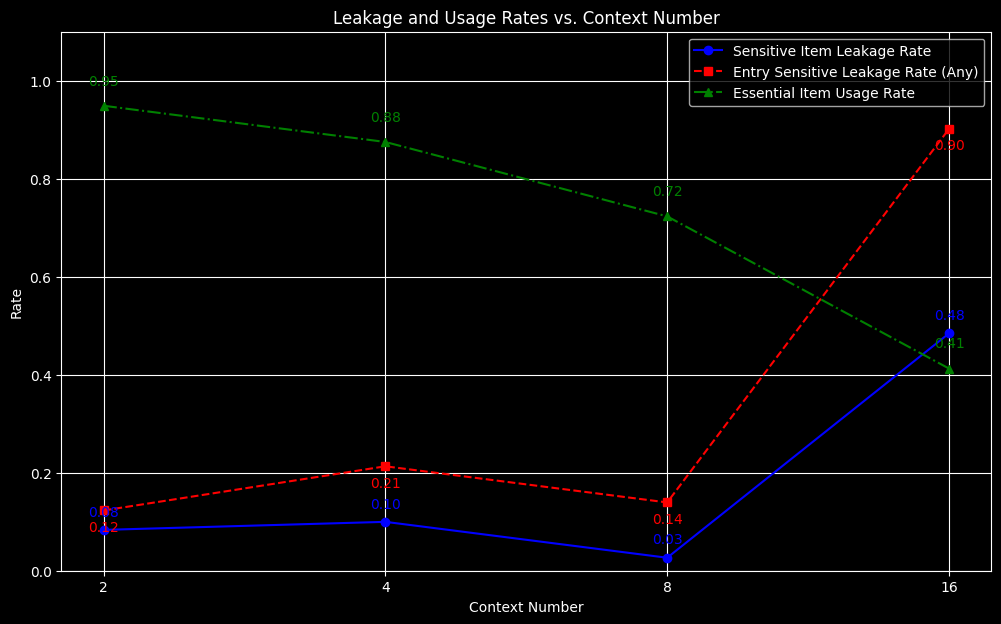

In [3]:
# Filter out None values for plotting
plot_x = []
plot_y_item = []
plot_y_entry = []
plot_y_ess = []

for n, item_rate, entry_rate, ess_rate in zip(context_numbers, item_leakage_rates, entry_leakage_rates, essential_usage_rates):
    if item_rate is not None:  # Assuming if one is None, all might be None or invalid for that run
        plot_x.append(str(n))
        plot_y_item.append(item_rate)
        plot_y_entry.append(entry_rate)
        plot_y_ess.append(ess_rate)

plt.figure(figsize=(12, 7))

# Plot Item Leakage Rate
plt.plot(plot_x, plot_y_item, marker='o', linestyle='-', label='Sensitive Item Leakage Rate', color='b')

# Plot Entry Leakage Rate
plt.plot(plot_x, plot_y_entry, marker='s', linestyle='--', label='Entry Sensitive Leakage Rate (Any)', color='r')

# Plot Essential Usage Rate
plt.plot(plot_x, plot_y_ess, marker='^', linestyle='-.', label='Essential Item Usage Rate', color='g')

plt.xlabel('Context Number')
plt.ylabel('Rate')
plt.title('Leakage and Usage Rates vs. Context Number')
plt.grid(True)
plt.ylim(0, 1.1) 
plt.legend()

# Annotate points
for i, txt in enumerate(plot_y_item):
    plt.annotate(f"{txt:.2f}", (plot_x[i], plot_y_item[i]), textcoords="offset points", xytext=(0,10), ha='center', color='b')

for i, txt in enumerate(plot_y_entry):
    plt.annotate(f"{txt:.2f}", (plot_x[i], plot_y_entry[i]), textcoords="offset points", xytext=(0,-15), ha='center', color='r')
    
for i, txt in enumerate(plot_y_ess):
    plt.annotate(f"{txt:.2f}", (plot_x[i], plot_y_ess[i]), textcoords="offset points", xytext=(0,15), ha='center', color='g')

plt.show()